In [1]:
from simplified import *

In [4]:
im4 = Raster.file(examples_dir / "IMG_0004.HEIC", cache_dir / "m2_out4.npy")

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

<Axes: >

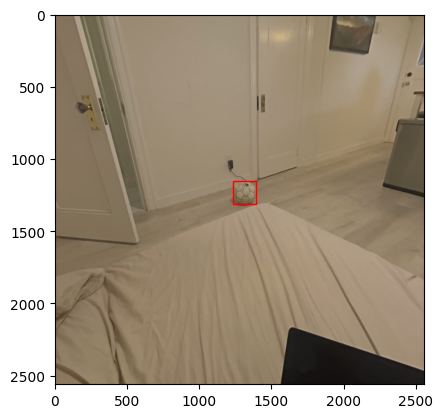

In [27]:
ax = plt.subplots()[1]
ax.imshow(im4.cropped())
ax.add_patch(patches.Rectangle((1230, 1150), 160, 160, linewidth=1, edgecolor='r', facecolor='none'))
ax

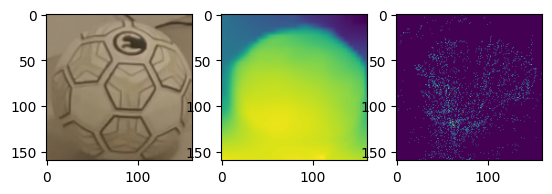

In [35]:
ax = plt.subplots(1, 3)[1]
ax[0].imshow(jnp.array(im4.cropped())[1150:1310, 1230:1390])
ax[1].imshow(im4.depth.depth[1150:1310, 1230:1390])
ax[2].imshow(im4.depth.binned().counts[1150:1310, 1230:1390])

In [36]:
im4 = M2.file(examples_dir / "IMG_0004.HEIC", cache_dir / "m2_out4.npy")

<Axes: >

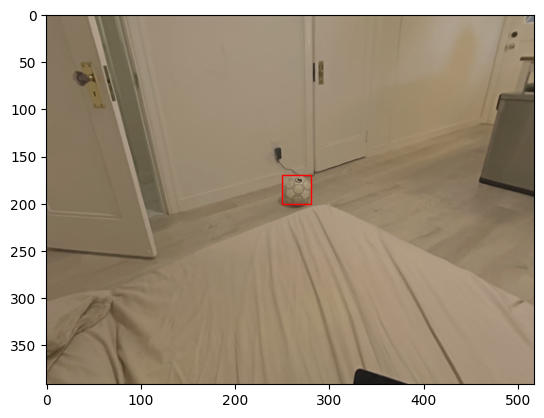

In [39]:
ax = plt.subplots()[1]
ax.imshow(im4.cropped())
ax.add_patch(patches.Rectangle((250, 170), 30, 30, linewidth=1, edgecolor='r', facecolor='none'))
ax

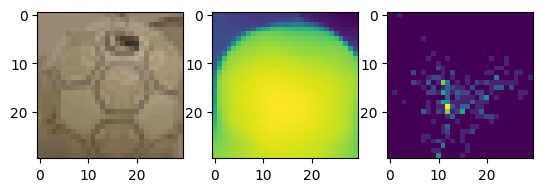

In [40]:
ax = plt.subplots(1, 3)[1]
crop = (slice(170, 200), slice(250, 280))
ax[0].imshow(jnp.array(im4.cropped())[crop])
ax[1].imshow(im4.depth.depth[crop])
ax[2].imshow(im4.depth.binned().counts[crop])

In [64]:
source_center = jnp.concat((im4.depth.coord, im4.depth.masked), axis=-1)
source_center = source_center[crop]
source_center = source_center[jnp.logical_and(crop[0].start <= source_center[..., 2], source_center[..., 2] < crop[0].stop)]
source_center = source_center[jnp.logical_and(crop[1].start <= source_center[..., 3], source_center[..., 3] < crop[1].stop)]
source_center = source_center.reshape(-1, 2, 2)

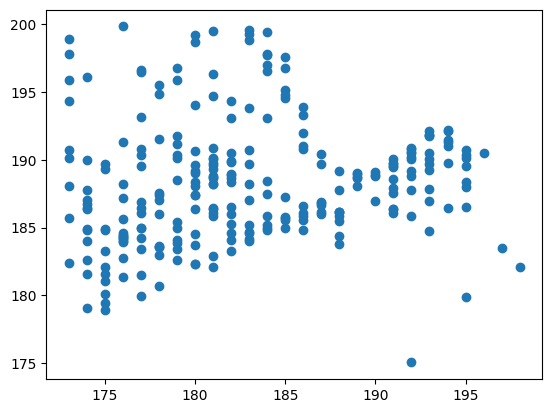

In [65]:
plt.scatter(source_center[..., 0, 0], source_center[..., 1, 0])

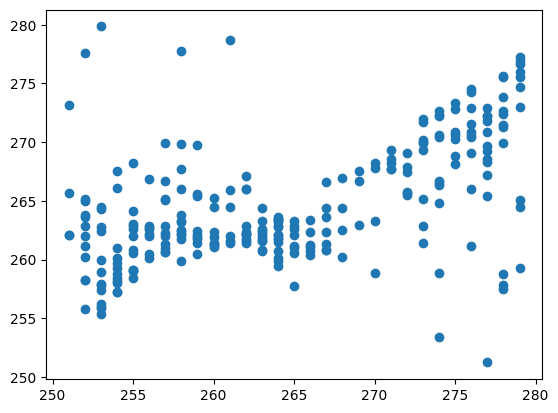

In [66]:
plt.scatter(source_center[..., 0, 1], source_center[..., 1, 1])